In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("data/stud.csv")

In [4]:
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [10]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [11]:
df.shape

(1000, 8)

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [13]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [14]:
df.duplicated().sum()

0

In [16]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [17]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [5]:
print('Categories in gender variable ',end=' ')
print(df['gender'].unique())

Categories in gender variable  ['female' 'male']


In [19]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


In [6]:
print(df['race/ethnicity'].unique())

['group B' 'group C' 'group A' 'group D' 'group E']


In [7]:
print(df['parental level of education'].unique())

["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']


In [8]:
print(df['lunch'].unique())

['standard' 'free/reduced']


In [9]:
print(df['test preparation course'].unique())

['none' 'completed']


In [10]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

In [12]:
print('We have {} numerical features: {}'.format(len(numerical_features),numerical_features))
print('We have {} categorical features: {}'.format(len(categorical_features),categorical_features))


We have 3 numerical features: ['math score', 'reading score', 'writing score']
We have 5 categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [16]:
#Adding columns for total score and average score
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score']/ len(numerical_features)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:
# Full Marks
reading_full = df[df['reading score'] == 100]['average score'].count()
warning_full = df[df['writing score'] == 100]['average score'].count()
math_full = df[df['math score'] == 100]['average score'].count()
print(f'Number of students with full marks in Reading {reading_full}')
print(f'Number of students with full marks in Writing {warning_full}')
print(f'Number of students with full marks in Math {math_full}')

Number of students with full marks in Reading 17
Number of students with full marks in Writing 14
Number of students with full marks in Math 7


In [21]:
# Less than 20
reading_less_20 = df[df['reading score'] <=20]['average score'].count()
writing_less_20 = df[df['writing score'] <=20]['average score'].count()
math_less_20 = df[df['math score'] <=20]['average score'].count()
print(f'Students with Less than 20 marks in Reading {reading_less_20}')
print(f'Students with Less than 20 marks in Writing {writing_less_20}')
print(f'Students with Less than 20 marks in Math {math_less_20}')

Students with Less than 20 marks in Reading 1
Students with Less than 20 marks in Writing 3
Students with Less than 20 marks in Math 4


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

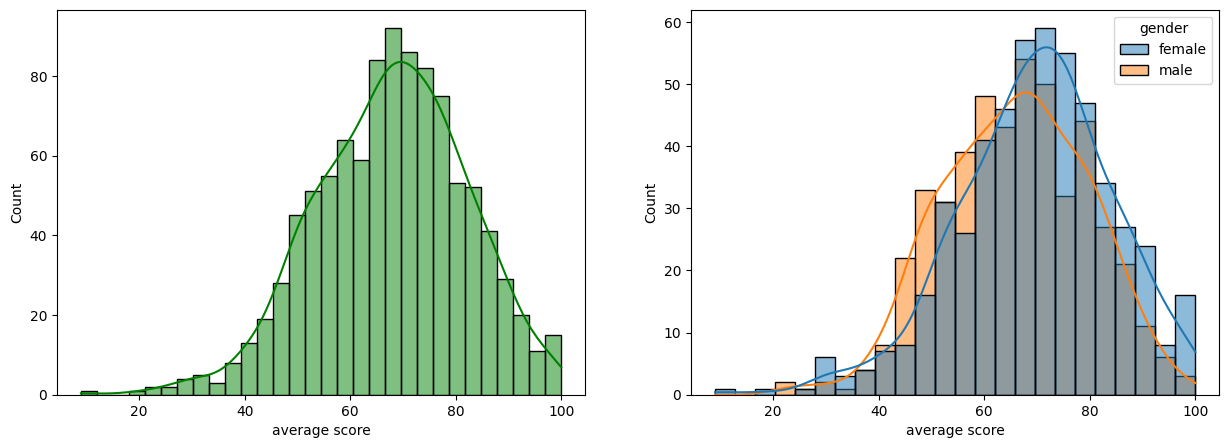

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(15,5))
plt.subplot(121)
sns.histplot(data=df,x='average score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average score',kde=True,hue='gender')
plt.show()


C:\Users\Meow\AppData\Local\Temp\ipykernel_12944\3274746682.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(141)
C:\Users\Meow\AppData\Local\Temp\ipykernel_12944\3274746682.py:4: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(142)
C:\Users\Meow\AppData\Local\Temp\ipykernel_12944\3274746682.py:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(143)


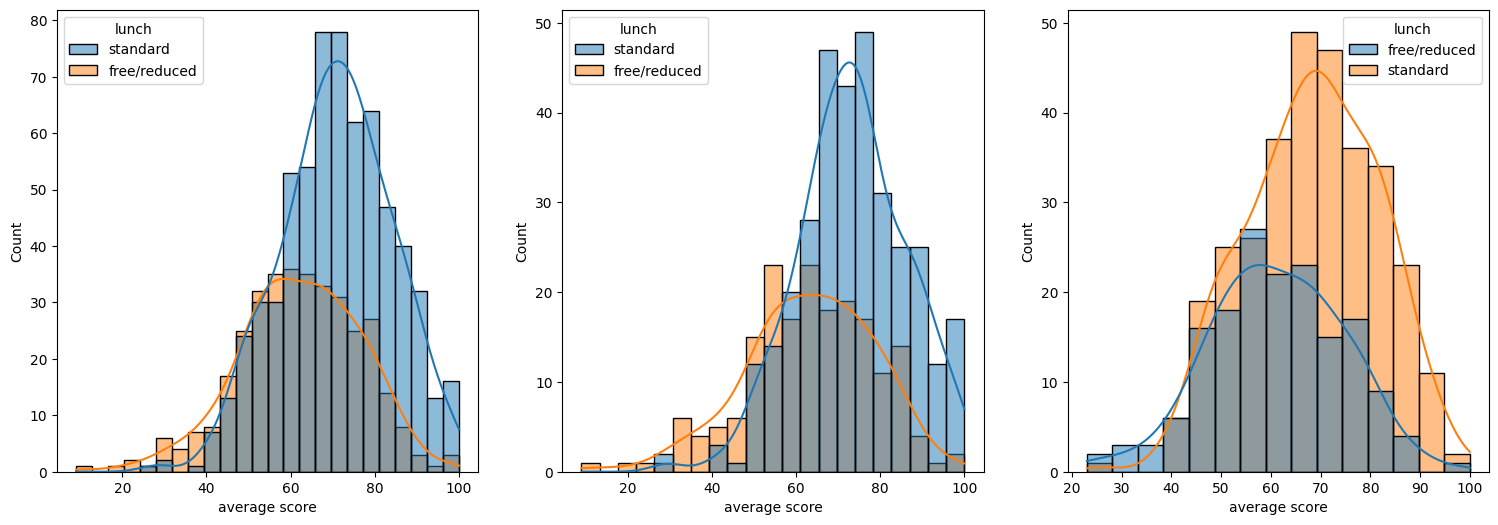

In [39]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average score', kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df['gender'] == 'female'],x='average score', kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df['gender'] == 'male'],x='average score', kde=True,hue='lunch')
plt.show()

In [40]:
!pip install catboost

  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
   ---------------------------------------- 0.0/100.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.3 MB ? eta -:--:--
    --------------------------------------- 2.4/100.3 MB 9.6 MB/s eta 0:00:11
   - -------------------------------------- 3.9/100.3 MB 8.4 MB/s eta 0:00:12
   -- ------------------------------------- 5.5/100.3 MB 8.0 MB/s eta 0:00:12
   -- ------------------------------------- 7.1/100.3 MB 7.8 MB/s eta 0:00:12
   --- ------------------------------------ 8.1/100.3 MB 7.3 MB/s eta 0:00:13
   --- ------------------------------------ 9.7/100.3 MB 7.5 MB/s eta 0:00:13
   ---- ----------------------------------- 10.7/100.3 MB 7.3 MB/s eta 0:00:13
   ---- ----------------------------------- 12.1/100.3 MB 6.9 MB/s eta 0:00:13
   ----- ---------------------------------- 13.1/100.3 MB 7.0 MB/s eta 0:00:13
   ----- ---------------------------------- 13.4/100.3 MB 6.4 MB/s eta 0:00:14
   ----- --